## Imports

In [1]:
import os
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## A. Data Preparation

In [2]:
url = "https://www.bgc-jena.mpg.de/wetter/mpi_saale_2021b.zip"
zip_path = "mpi_saale_2021b.zip"
csv_path = "mpi_saale_2021b.csv"

if not os.path.exists(csv_path):
    r = requests.get(url)
    with open(zip_path, 'wb') as f:
        f.write(r.content)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Downloaded and extracted")
else:
    print("Dataset already exists")

Dataset already exists


In [3]:
df = pd.read_csv(csv_path)

# Convert to datetime and resample to daily max temp
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df.set_index('Date Time', inplace=True)

# Resample to daily mean
df_daily = df[['T (degC)']].resample('D').mean()
df_daily.dropna(inplace=True)

target_col = 'T (degC)'
seq_length = 30
pred_length = 1
data = df_daily[target_col].values.reshape(-1, 1)

In [4]:
def create_sequences(data, seq_length, pred_length=1):
    X, y = [], []
    for i in range(len(data) - seq_length - pred_length + 1):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length:i + seq_length + pred_length])
    return np.array(X), np.array(y)

In [5]:
# 1. Compute stats ONLY on training portion to prevent data leakage
train_split_idx = int(len(data) * 0.7)
train_data = data[:train_split_idx]
train_mean = np.mean(train_data)
train_std = np.std(train_data)

# 2. Scale all data using training stats
data_scaled = (data - train_mean) / train_std

X, y = create_sequences(data_scaled, seq_length, pred_length)

# 3. Split the created sequences
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

# 4. Convert to tensors
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

# 5. Use TensorDataset
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)

## B. Implement LSTM Model

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred.squeeze(), y_batch.squeeze())
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
            
        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)
        
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t)
            val_loss = criterion(val_preds.squeeze(), y_val_t.squeeze()).item()
            val_losses.append(val_loss)
            
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            
    return train_losses, val_losses

In [7]:
lstm_model = LSTMModel().to(device)
lstm_train_losses, lstm_val_losses = train_model(lstm_model, train_loader, val_loader, epochs=200)

Epoch 10/200, Train Loss: 0.7244, Val Loss: 1.5204
Epoch 20/200, Train Loss: 0.3742, Val Loss: 0.5478
Epoch 30/200, Train Loss: 0.3433, Val Loss: 0.5035
Epoch 40/200, Train Loss: 0.3231, Val Loss: 0.4776
Epoch 50/200, Train Loss: 0.3157, Val Loss: 0.4356
Epoch 60/200, Train Loss: 0.3084, Val Loss: 0.4052
Epoch 70/200, Train Loss: 0.3009, Val Loss: 0.3830
Epoch 80/200, Train Loss: 0.2927, Val Loss: 0.3678
Epoch 90/200, Train Loss: 0.2837, Val Loss: 0.3552
Epoch 100/200, Train Loss: 0.2739, Val Loss: 0.3401
Epoch 110/200, Train Loss: 0.2621, Val Loss: 0.3255
Epoch 120/200, Train Loss: 0.2475, Val Loss: 0.3146
Epoch 130/200, Train Loss: 0.2302, Val Loss: 0.3048
Epoch 140/200, Train Loss: 0.2101, Val Loss: 0.2848
Epoch 150/200, Train Loss: 0.2205, Val Loss: 0.2517
Epoch 160/200, Train Loss: 0.1805, Val Loss: 0.2522
Epoch 170/200, Train Loss: 0.1681, Val Loss: 0.2370
Epoch 180/200, Train Loss: 0.1659, Val Loss: 0.2183
Epoch 190/200, Train Loss: 0.1523, Val Loss: 0.2138
Epoch 200/200, Train 

## C. Implement GRU Model

In [8]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [9]:
gru_model = GRUModel().to(device)
gru_train_losses, gru_val_losses = train_model(gru_model, train_loader, val_loader, epochs=200)

Epoch 10/200, Train Loss: 0.5104, Val Loss: 0.8538
Epoch 20/200, Train Loss: 0.2964, Val Loss: 0.3178
Epoch 30/200, Train Loss: 0.2828, Val Loss: 0.3217
Epoch 40/200, Train Loss: 0.2684, Val Loss: 0.3149
Epoch 50/200, Train Loss: 0.2530, Val Loss: 0.3050
Epoch 60/200, Train Loss: 0.2361, Val Loss: 0.2943
Epoch 70/200, Train Loss: 0.2174, Val Loss: 0.2833
Epoch 80/200, Train Loss: 0.1972, Val Loss: 0.2729
Epoch 90/200, Train Loss: 0.1790, Val Loss: 0.2583
Epoch 100/200, Train Loss: 0.1656, Val Loss: 0.2430
Epoch 110/200, Train Loss: 0.1558, Val Loss: 0.2359
Epoch 120/200, Train Loss: 0.1490, Val Loss: 0.2316
Epoch 130/200, Train Loss: 0.1443, Val Loss: 0.2289
Epoch 140/200, Train Loss: 0.1407, Val Loss: 0.2276
Epoch 150/200, Train Loss: 0.1377, Val Loss: 0.2277
Epoch 160/200, Train Loss: 0.1349, Val Loss: 0.2289
Epoch 170/200, Train Loss: 0.1320, Val Loss: 0.2308
Epoch 180/200, Train Loss: 0.1291, Val Loss: 0.2337
Epoch 190/200, Train Loss: 0.1259, Val Loss: 0.2372
Epoch 200/200, Train 

## Baseline Benchmark

In [10]:
# Naive baseline: predict the last observed value
baseline_preds = X_test_t.cpu().numpy()[:, -1, 0]
y_test_np = y_test_t.cpu().numpy().squeeze()
baseline_mae = np.mean(np.abs(y_test_np - baseline_preds.squeeze()))
baseline_rmse = np.sqrt(np.mean((y_test_np - baseline_preds.squeeze())**2))
print(f'Baseline MAE: {baseline_mae:.4f}, RMSE: {baseline_rmse:.4f}')


Baseline MAE: 0.7030, RMSE: 0.9320


## D. Evaluation

In [11]:
lstm_model.eval()
gru_model.eval()
with torch.no_grad():
    lstm_preds = lstm_model(X_test_t).cpu().numpy()
    gru_preds = gru_model(X_test_t).cpu().numpy()

y_test_np = y_test_t.cpu().numpy().squeeze()
lstm_mae = np.mean(np.abs(y_test_np - lstm_preds.squeeze()))
lstm_rmse = np.sqrt(np.mean((y_test_np - lstm_preds.squeeze())**2))
gru_mae = np.mean(np.abs(y_test_np - gru_preds.squeeze()))
gru_rmse = np.sqrt(np.mean((y_test_np - gru_preds.squeeze())**2))

print(f'LSTM MAE: {lstm_mae:.4f}, RMSE: {lstm_rmse:.4f}')
print(f'GRU MAE: {gru_mae:.4f}, RMSE: {gru_rmse:.4f}')


LSTM MAE: 0.7204, RMSE: 0.8805
GRU MAE: 0.6415, RMSE: 0.8564


## E. Hyperparameter Experiments

In [12]:
# Train a second LSTM with 128 hidden units
lstm_model_2 = LSTMModel(hidden_size=128).to(device)
_, _ = train_model(lstm_model_2, train_loader, val_loader, epochs=100)
lstm_model_2.eval()
with torch.no_grad():
    lstm_preds_2 = lstm_model_2(X_test_t).cpu().numpy()

y_test_np = y_test_t.cpu().numpy().squeeze()
lstm_mae_2 = np.mean(np.abs(y_test_np - lstm_preds_2.squeeze()))
print(f'LSTM (128 units) MAE: {lstm_mae_2:.4f}')


Epoch 10/100, Train Loss: 0.4227, Val Loss: 0.6523
Epoch 20/100, Train Loss: 0.3369, Val Loss: 0.4968
Epoch 30/100, Train Loss: 0.3269, Val Loss: 0.4637
Epoch 40/100, Train Loss: 0.3184, Val Loss: 0.4291
Epoch 50/100, Train Loss: 0.3090, Val Loss: 0.3960
Epoch 60/100, Train Loss: 0.2987, Val Loss: 0.3684
Epoch 70/100, Train Loss: 0.2866, Val Loss: 0.3463
Epoch 80/100, Train Loss: 0.2716, Val Loss: 0.3267
Epoch 90/100, Train Loss: 0.2511, Val Loss: 0.3048
Epoch 100/100, Train Loss: 0.2239, Val Loss: 0.2768
LSTM (128 units) MAE: 0.7812


In [13]:
# Train a second GRU with 128 hidden units
gru_model_2 = GRUModel(hidden_size=128).to(device)
_, _ = train_model(gru_model_2, train_loader, val_loader, epochs=100)
gru_model_2.eval()
with torch.no_grad():
    gru_preds_2 = gru_model_2(X_test_t).cpu().numpy()

y_test_np = y_test_t.cpu().numpy().squeeze()
gru_mae_2 = np.mean(np.abs(y_test_np - gru_preds_2.squeeze()))
print(f'LSTM (128 units) MAE: {gru_mae_2:.4f}')

Epoch 10/100, Train Loss: 0.4080, Val Loss: 0.6426
Epoch 20/100, Train Loss: 0.3098, Val Loss: 0.2986
Epoch 30/100, Train Loss: 0.2907, Val Loss: 0.2987
Epoch 40/100, Train Loss: 0.2714, Val Loss: 0.2864
Epoch 50/100, Train Loss: 0.2504, Val Loss: 0.2787
Epoch 60/100, Train Loss: 0.2270, Val Loss: 0.2731
Epoch 70/100, Train Loss: 0.2018, Val Loss: 0.2617
Epoch 80/100, Train Loss: 0.1780, Val Loss: 0.2415
Epoch 90/100, Train Loss: 0.1615, Val Loss: 0.2288
Epoch 100/100, Train Loss: 0.1517, Val Loss: 0.2292
LSTM (128 units) MAE: 0.7173


## F. Visualization

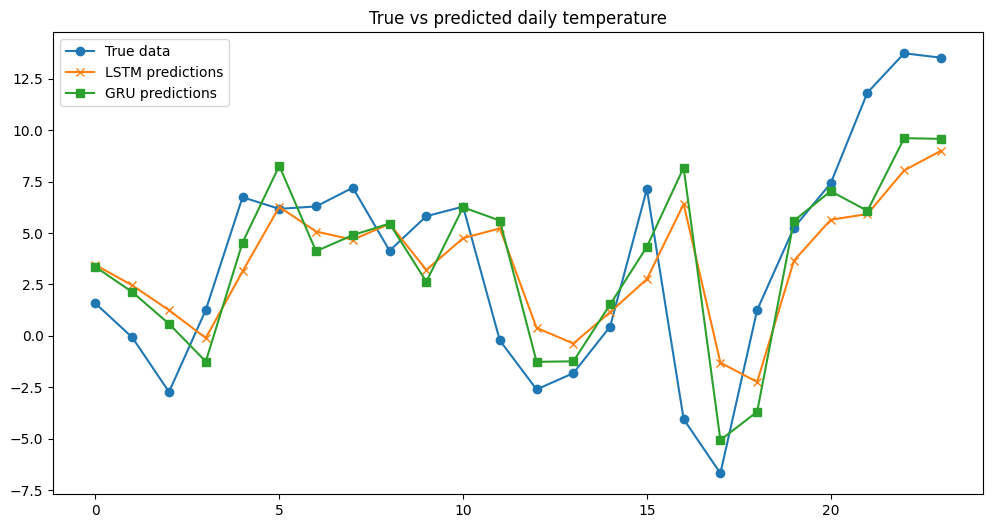

In [18]:
y_test_np = y_test_t.cpu().numpy().squeeze()
y_test_inv = (y_test_np * train_std) + train_mean
lstm_preds_inv = (lstm_preds.squeeze() * train_std) + train_mean
gru_preds_inv = (gru_preds.squeeze() * train_std) + train_mean

plt.figure(figsize=(12, 6))
plt.plot(y_test_inv[-30:], label='True data', marker='o')
plt.plot(lstm_preds_inv[-30:], label='LSTM predictions', marker='x')
plt.plot(gru_preds_inv[-30:], label='GRU predictions', marker='s')
plt.title('True vs predicted daily temperature')
plt.legend()
plt.show()


## G. Interpretability Discussion

In [15]:
def calculate_timestep_importance(model, X_test, y_test, criterion=nn.MSELoss()):
    model.eval()
    
    with torch.no_grad():
        baseline_preds = model(X_test)
        baseline_loss = criterion(baseline_preds.squeeze(), y_test.squeeze()).item()
    
    seq_length = X_test.size(1)
    importance_scores = []
    
    for t in range(seq_length):
        X_perturbed = X_test.clone()
        X_perturbed[:, t, :] = 0.0 
        
        with torch.no_grad():
            perturbed_preds = model(X_perturbed)
            perturbed_loss = criterion(perturbed_preds.squeeze(), y_test.squeeze()).item()
            

        importance = perturbed_loss - baseline_loss
        importance_scores.append(importance)
        
    return importance_scores

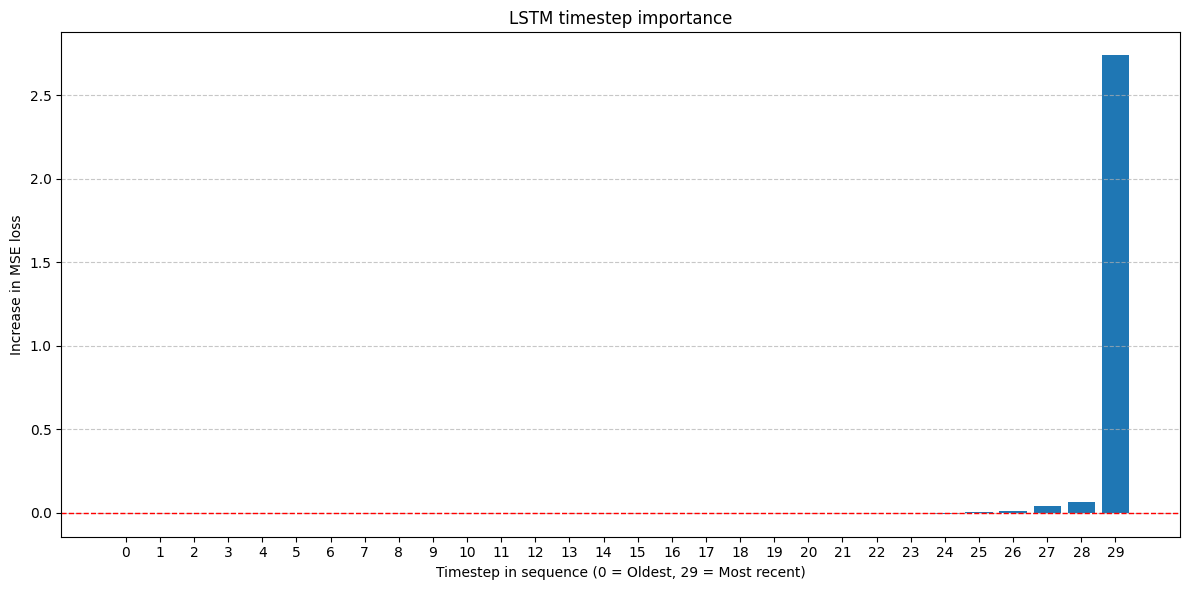

In [16]:
timestep_importance = calculate_timestep_importance(lstm_model, X_test_t, y_test_t)


plt.figure(figsize=(12, 6))
plt.bar(range(len(timestep_importance)), timestep_importance)
plt.title("LSTM timestep importance")
plt.xlabel("Timestep in sequence (0 = Oldest, 29 = Most recent)")
plt.ylabel("Increase in MSE loss")
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xticks(range(0, 30))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

We analyzed the model by systematically masking each timestep (replacing with the mean/0) and observing the drop in performance.

Recent timesteps (days 27-29) have a much higher positive bar.

This indicates the LSTM relies heavily on the most immediate history to make its short-term forecast, which aligns with the strong 'persistence' nature of temperature data.